In [2]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")
df=pd.read_csv(path + "/AmesHousing.csv")
df.head()

100%|██████████| 185k/185k [00:00<00:00, 55.2MB/s]

Extracting files...


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
#Analyzing the data
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,490
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


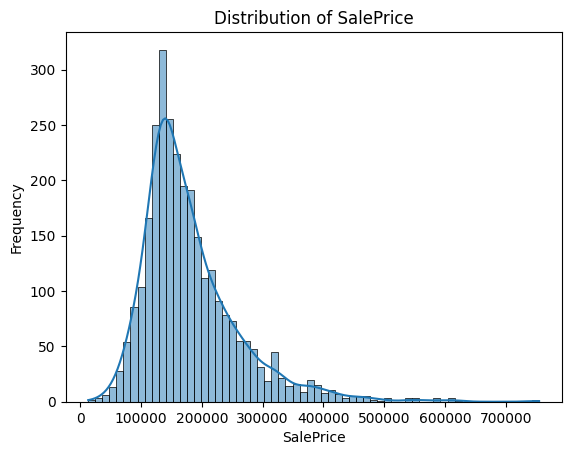

In [4]:
X=df.drop('SalePrice', axis=1)
y=df['SalePrice']
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(y, kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

In [5]:
#data cleaning and preprocessing
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
#handle the outliers and skewness in the target variable (SalePrice) by applying log transformation and using IQR method to remove outliers.
from sklearn.preprocessing import FunctionTransformer
import numpy as np
#apply log transformation to the target variable
y_log = np.log1p(y)
Q1 = y_log.quantile(0.25)
Q3 = y_log.quantile(0.75)
IQR= Q3 - Q1
#filter out the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
#filter the dataset to remove outliers
mask = (y_log >= lower_bound) & (y_log <= upper_bound)
X = X[mask]
y = y[mask]
y_log = y_log[mask]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
from sklearn.linear_model import LinearRegression
model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



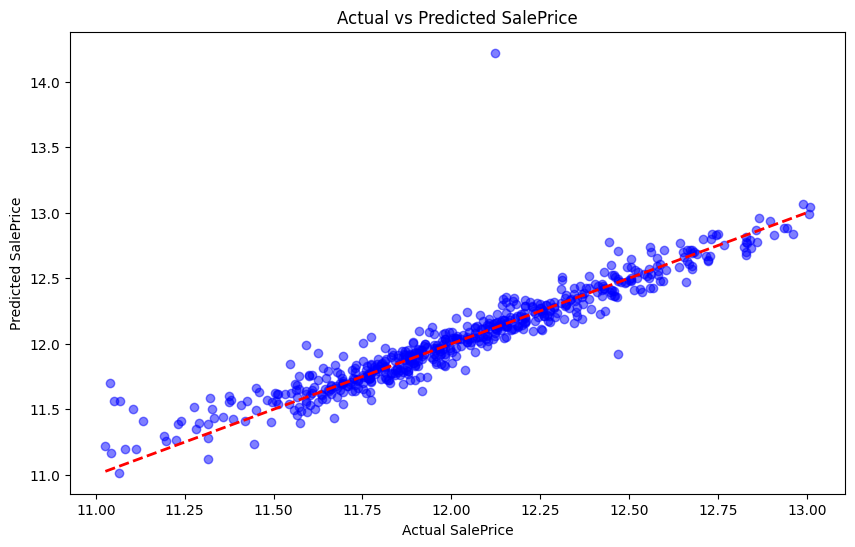

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.show()
 

In [7]:
#evalauting the models perfomance over training and testing data using RMSE, MEA, R2 SCORE, MSE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Testing RMSE: {rmse}")
print(f"Testing MAE: {mae}")
print(f"Testing R2 Score: {r2}")
print(f"Testing MSE: {mse}")
#evalauting over training data
y_train_pred = model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"Training RMSE: {rmse_train}")
print(f"Training MAE: {mae_train}")
print(f"Training R2 Score: {r2_train}")
print(f"Training MSE: {mse_train}")


Testing RMSE: 0.13543430192344452
Testing MAE: 0.07602784532120181
Testing R2 Score: 0.8780197704744875
Testing MSE: 0.01834245013749073
Training RMSE: 0.09165854786113738
Training MAE: 0.06416333405975665
Training R2 Score: 0.9367279683354781
Training MSE: 0.008401289396012411


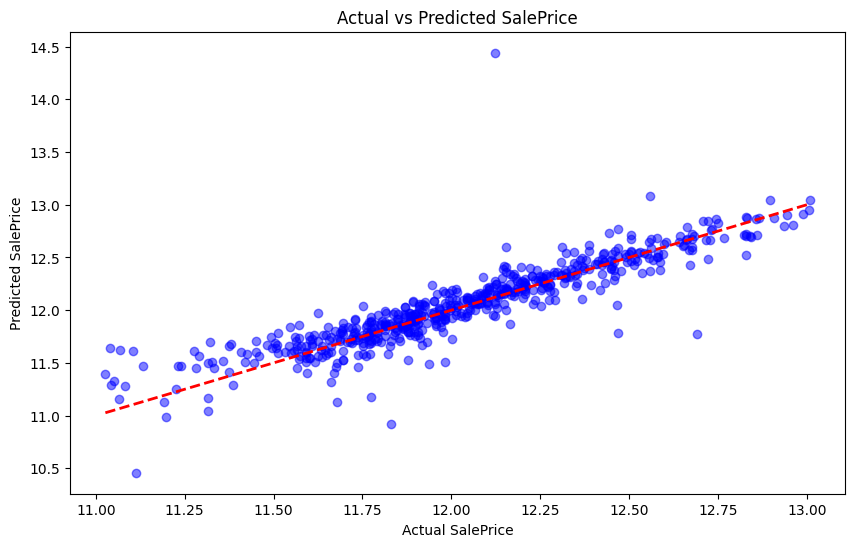

In [9]:
from sklearn.linear_model import SGDRegressor

#now using SGDRegressor instead of LinearRegression
#now using SGDRegressor instead of LinearRegression
model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', SGDRegressor(
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    max_iter=10000,
    random_state=42
))])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.show()

In [10]:
#evalauting the models perfomance over training and testing data using RMSE, MEA, R2 SCORE, MSE for SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Testing RMSE: {rmse}")
print(f"Testing MAE: {mae}")
print(f"Testing R2 Score: {r2}")
print(f"Testing MSE: {mse}")
#evalauting over training data
y_train_pred = model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"Training RMSE: {rmse_train}")
print(f"Training MAE: {mae_train}")
print(f"Training R2 Score: {r2_train}")
print(f"Training MSE: {mse_train}")


Testing RMSE: 0.1803905190495641
Testing MAE: 0.10844383343549385
Testing R2 Score: 0.7835988743776349
Testing MSE: 0.03254073936297115
Training RMSE: 0.13774649978263068
Training MAE: 0.0971145845360678
Training R2 Score: 0.8571017274044045
Training MSE: 0.018974098202366275


In [16]:
#now applying Ridge Regression
from sklearn.linear_model import Ridge
ridge_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=10.985411419875572))])
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
#evalauting the models perfomance over training and testing data using RMSE, MEA, R2 SCORE, MSE for Ridge Regression
rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_pred))
mae_ridge = mean_absolute_error(y_test, ridge_pred)
r2_ridge = r2_score(y_test, ridge_pred)
mse_ridge = mean_squared_error(y_test, ridge_pred)
print(f"Testing RMSE (Ridge): {rmse_ridge}")
print(f"Testing MAE (Ridge): {mae_ridge}")
print(f"Testing R2 Score (Ridge): {r2_ridge}")
print(f"Testing MSE (Ridge): {mse_ridge}")
#on training data
y_train_ridge_pred = ridge_model.predict(X_train)
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_ridge_pred))
mae_train_ridge = mean_absolute_error(y_train, y_train_ridge_pred)
r2_train_ridge = r2_score(y_train, y_train_ridge_pred)
mse_train_ridge = mean_squared_error(y_train, y_train_ridge_pred)
print(f"Training RMSE (Ridge): {rmse_train_ridge}")
print(f"Training MAE (Ridge): {mae_train_ridge}")
print(f"Training R2 Score (Ridge): {r2_train_ridge}")
print(f"Training MSE (Ridge): {mse_train_ridge}")


Testing RMSE (Ridge): 0.1290670165998842
Testing MAE (Ridge): 0.07862587491834726
Testing R2 Score (Ridge): 0.8892196732277171
Testing MSE (Ridge): 0.016658294773994782
Training RMSE (Ridge): 0.10252974687382894
Training MAE (Ridge): 0.07069543627637911
Training R2 Score (Ridge): 0.9208290957417444
Training MSE (Ridge): 0.010512348994011435


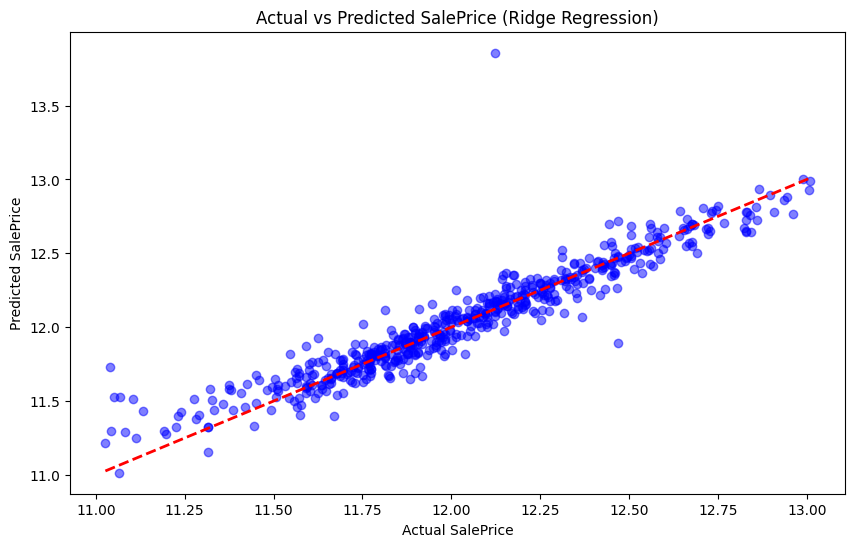

In [17]:
#plotting the actual vs predicted values for Ridge Regression with line of best fit
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, ridge_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice (Ridge Regression)')
plt.show()

In [18]:
#now applying Lasso Regression
from sklearn.linear_model import Lasso
lasso_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(alpha=0.001))])
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
#evalauting the models perfomance over training and testing data using RMSE, MEA, R2 SCORE, MSE for Lasso Regression
rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_pred))
mae_lasso = mean_absolute_error(y_test, lasso_pred)
r2_lasso = r2_score(y_test, lasso_pred)
mse_lasso = mean_squared_error(y_test, lasso_pred)
print(f"Testing RMSE (Lasso): {rmse_lasso}")
print(f"Testing MAE (Lasso): {mae_lasso}")
print(f"Testing R2 Score (Lasso): {r2_lasso}")
print(f"Testing MSE (Lasso): {mse_lasso}")
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, lasso_model.predict(X_train)))
mae_train_lasso = mean_absolute_error(y_train, lasso_model.predict(X_train))
r2_train_lasso = r2_score(y_train, lasso_model.predict(X_train))
mse_train_lasso = mean_squared_error(y_train, lasso_model.predict(X_train))
print(f"Training RMSE (Lasso): {rmse_train_lasso}")
print(f"Training MAE (Lasso): {mae_train_lasso}")
print(f"Training R2 Score (Lasso): {r2_train_lasso}")
print(f"Training MSE (Lasso): {mse_train_lasso}")


Testing RMSE (Lasso): 0.1306122167144714
Testing MAE (Lasso): 0.08116325066510588
Testing R2 Score (Lasso): 0.8865512540637008
Testing MSE (Lasso): 0.01705955115506804
Training RMSE (Lasso): 0.11321014629763906
Training MAE (Lasso): 0.07610310368979602
Training R2 Score (Lasso): 0.9034757272499482
Training MSE (Lasso): 0.012816537224732841


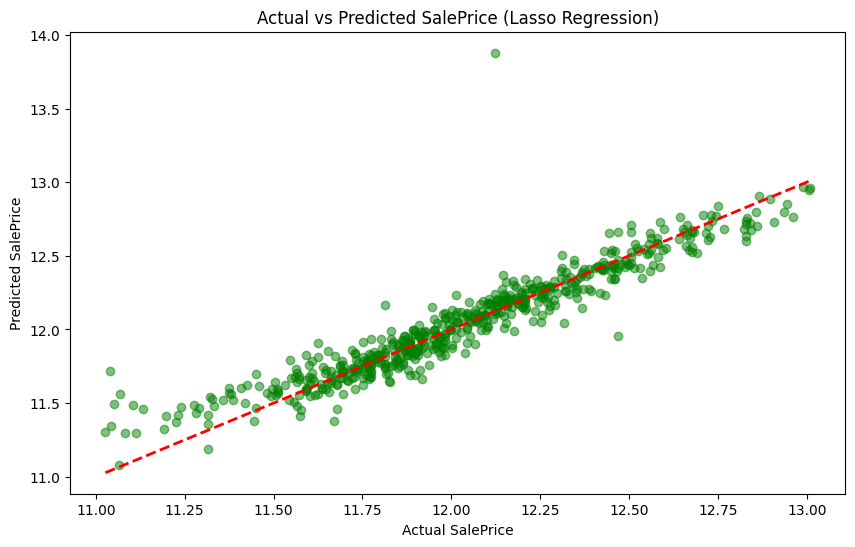

In [19]:
#plotting the actual vs predicted values for lasso Regression with line of best fit
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lasso_pred, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice (Lasso Regression)')
plt.show()

In [20]:
#now applying ElasticNet Regression
from sklearn.linear_model import ElasticNet
elastic_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', ElasticNet(alpha=0.01, l1_ratio=0.3))])
elastic_model.fit(X_train, y_train)
elastic_pred = elastic_model.predict(X_test)
#evalauting the models perfomance over training and testing data using RMSE, MEA, R2 SCORE, MSE for ElasticNet Regression
rmse_elastic = np.sqrt(mean_squared_error(y_test, elastic_pred))
mae_elastic = mean_absolute_error(y_test, elastic_pred)
r2_elastic = r2_score(y_test, elastic_pred)
mse_elastic = mean_squared_error(y_test, elastic_pred)
print(f"Testing RMSE (ElasticNet): {rmse_elastic}")
print(f"Testing MAE (ElasticNet): {mae_elastic}")
print(f"Testing R2 Score (ElasticNet): {r2_elastic}")
print(f"Testing MSE (ElasticNet): {mse_elastic}")
rmse_train_elastic = np.sqrt(mean_squared_error(y_train, elastic_model.predict(X_train )))
mae_train_elastic = mean_absolute_error(y_train, elastic_model.predict(X_train))
r2_train_elastic = r2_score(y_train, elastic_model.predict(X_train))
mse_train_elastic = mean_squared_error(y_train, elastic_model.predict(X_train))
print(f"Training RMSE (ElasticNet): {rmse_train_elastic}")
print(f"Training MAE (ElasticNet): {mae_train_elastic}")
print(f"Training R2 Score (ElasticNet): {r2_train_elastic}")
print(f"Training MSE (ElasticNet): {mse_train_elastic}")


Testing RMSE (ElasticNet): 0.14067095029930146
Testing MAE (ElasticNet): 0.0886179762641988
Testing R2 Score (ElasticNet): 0.8684045293298139
Testing MSE (ElasticNet): 0.019788316258108545
Training RMSE (ElasticNet): 0.12356458972183781
Training MAE (ElasticNet): 0.0840467857305653
Training R2 Score (ElasticNet): 0.885011635245349
Training MSE (ElasticNet): 0.015268207833126109


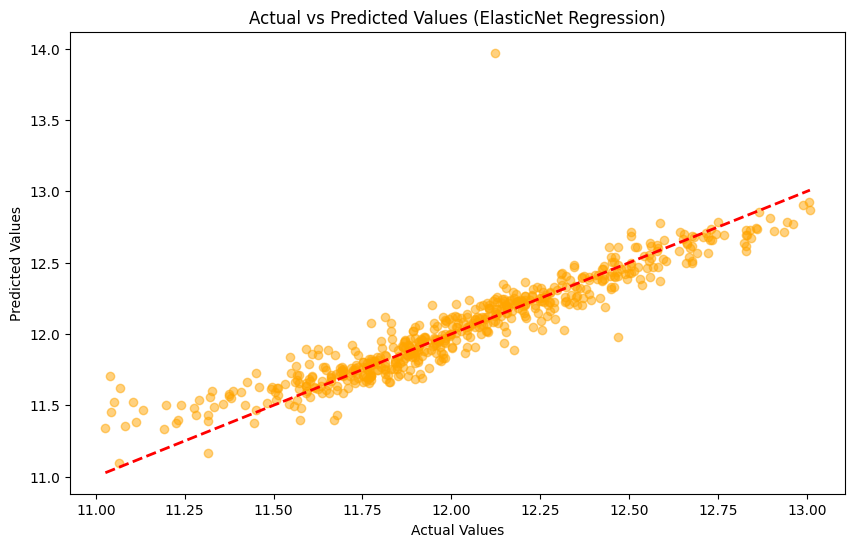

In [21]:
#plotting the actual vs predicted values for ElasticNet Regression with line of best fit
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, elastic_pred, color='orange', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (ElasticNet Regression)')
plt.show()

In [15]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
import numpy as np

alphas = np.logspace(-3, 3, 50)  # tests a wide range: 0.001 to 1000

ridge_cv = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', RidgeCV(alphas=alphas, cv=5))])
ridge_cv.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_cv.named_steps['regressor'].alpha_)

lasso_cv = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', LassoCV(alphas=alphas, cv=5, max_iter=5000))])
lasso_cv.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_cv.named_steps['regressor'].alpha_)

elastic_cv = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', ElasticNetCV(alphas=alphas, l1_ratio=[.1,.3,.5,.7,.9,1], cv=5, max_iter=5000))])
elastic_cv.fit(X_train, y_train)
print("Best ElasticNet alpha:", elastic_cv.named_steps['regressor'].alpha_,
      "l1_ratio:", elastic_cv.named_steps['regressor'].l1_ratio_)

Best Ridge alpha: 10.985411419875572
Best Lasso alpha: 0.001
Best ElasticNet alpha: 0.001 l1_ratio: 0.3
